In [18]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process, homogeneous_gamma_process

from ElephantClient import ElephantClientAPI

In [24]:
np.random.seed(28)  # to make the results reproducible
spiketrain1 = homogeneous_poisson_process(rate=10*Hz, t_start=0.*ms, t_stop=10000.*ms)
spiketrain2 = homogeneous_gamma_process(a=3, b=10*Hz, t_start=0.*ms, t_stop=10000.*ms)

In [25]:
st1 = dict(times=spiketrain1.as_array().tolist(), units='ms', t_stop=10000)
st2 = dict(times=spiketrain2.as_array().tolist(), units='ms', t_stop=10000)

In [26]:
ElAPI = ElephantClientAPI('http://localhost:5001', 'statistics')

In [39]:
ElAPI.cv(data=dict(a=st1), units={'time': 's'})

<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>400 Bad Request</title>
<h1>Bad Request</h1>
<p>ElephantRuntimeError(&#x27;TypeError(&quot;unsupported operand type(s) for /: \&#x27;dict\&#x27; and \&#x27;int\&#x27;&quot;)&#x27;)</p>



In [28]:
ElAPI.isi(data=dict(spiketrain=[1,2,3,4,11]), units=dict(time='ms'))

[1.0, 1.0, 1.0, 7.0]

In [29]:
ElAPI.mean_firing_rate(data=dict(spiketrain=st1), units=dict(time='s'))

8.6

In [30]:
data = dict(spiketrain=st1); units=dict(time='ms')
ElAPI.isi(data=data, units=units)

[82.38018060843254,
 13.349378419943235,
 50.68209344161971,
 152.00918749731318,
 71.53784371626392,
 20.174092824301,
 192.08177400448835,
 310.9391408473182,
 414.8598123465256,
 21.40611388588286,
 353.34188224843206,
 26.762895966885026,
 2.670733550488876,
 291.988932200557,
 254.75251212693365,
 34.81057188654313,
 18.185011058101736,
 50.322597411584866,
 71.47176284309944,
 36.82231232086633,
 56.136277180941306,
 177.23651938320018,
 82.64353375635801,
 177.71958960338225,
 578.5846826982406,
 40.43339558927164,
 9.541912476432572,
 148.64752413413498,
 16.179416925920577,
 129.22761415293007,
 310.43521912425285,
 7.590503565348627,
 59.269162625329045,
 183.9593917237744,
 15.728519956675882,
 144.93259053145266,
 152.2274088194099,
 112.41718036409293,
 14.122051946502324,
 4.009640591630159,
 106.71807081335828,
 28.92601355061379,
 445.8336268354178,
 76.22465818570527,
 6.099838792892115,
 119.98324344384127,
 98.66455119607781,
 226.12372088136544,
 17.664729095280563,

In [34]:
bin_size = 0.5

a = ElAPI.time_histogram(data=dict(spiketrains=[st1,st2], bin_size=bin_size, output='rate'), units=dict(time='s'))
print(a)

{'signal': {'sampling_rate': 2.0, 'times': [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5], 'units': '1/s', 'values': [[6.0, 4.0, 5.0, 4.0, 7.0, 6.0, 2.0, 7.0, 6.0, 6.0, 6.0, 7.0, 8.0, 6.0, 5.0, 4.0, 5.0, 6.0, 8.0, 9.0]]}}


<BarContainer object of 20 artists>

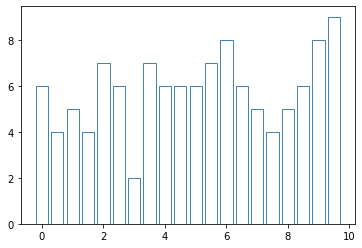

In [38]:
plt.bar(a['signal']['times'], a['signal']['values'][0], width=0.8*bin_size, color="none", edgecolor="steelblue")